# PHQ-8 Depression Detection — Simple CNN (Regression)

**Architecture**: 2 convolutional blocks (Conv2D → BatchNorm → ReLU → MaxPool), adaptive average pooling, lightweight FC head.

**Motivation**: The 3-block CNN (~634K params) overfits immediately — dev MSE diverges from epoch 1. This notebook uses a much smaller model (~38K params) to reduce overfitting.

**Input**: log-mel spectrograms `(1, 128, 801)` saved as `.npy` files.

**Target**: PHQ-8 score (continuous, 0–24).

## 1. Imports & Configuration

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam

import matplotlib.pyplot as plt
from scipy.stats import pearsonr

In [2]:
# Paths
BASE_DIR = Path("..") 
PROCESSED_DIR = BASE_DIR / "processed"
META_CSV = PROCESSED_DIR / "segment_metadata.csv"
SPEC_ROOT = PROCESSED_DIR / "spectrograms"
SAVE_DIR = BASE_DIR / "best_model" / "simple_cnn"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Training hyper-parameters
BATCH_SIZE = 64
NUM_EPOCHS = 100
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-3
CHECKPOINT_FREQ = 10
EARLY_STOPPING_PATIENCE = 10
NUM_WORKERS = 0

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
if DEVICE.type == "cpu":
    print("  WARNING: No GPU detected — training will be significantly slower.")
print(f"Checkpoints will be saved to: {SAVE_DIR.resolve()}")

Using device: cuda
Checkpoints will be saved to: C:\Users\edgar\OneDrive\Documents\Term_8\Deep_learning\Project\phq8_depression_detection\best_model\simple_cnn


## 2. Dataset

In [3]:
def spec_augment(spec, n_freq_masks=2, freq_mask_width=10, n_time_masks=2, time_mask_width=50):
    """
    SpecAugment: randomly zero-out horizontal (frequency) and vertical (time)
    bands of a spectrogram.  Applied in-place on a (n_mels, n_frames) tensor.
    """
    n_mels, n_frames = spec.shape
    for _ in range(n_freq_masks):
        f = torch.randint(0, freq_mask_width + 1, (1,)).item()
        f0 = torch.randint(0, max(n_mels - f, 1), (1,)).item()
        spec[f0 : f0 + f, :] = 0.0
    for _ in range(n_time_masks):
        t = torch.randint(0, time_mask_width + 1, (1,)).item()
        t0 = torch.randint(0, max(n_frames - t, 1), (1,)).item()
        spec[:, t0 : t0 + t] = 0.0
    return spec

class SpectrogramDataset(Dataset):
    def __init__(self, meta_df: pd.DataFrame, spec_root: Path, split: str):
        self.meta = meta_df.reset_index(drop=True)
        self.split_dir = spec_root / split
        self.augment = (split == "train")

    def __len__(self):
        return len(self.meta)

    def __getitem__(self, idx):
        row = self.meta.iloc[idx]
        pid = int(row["participant_id"])
        seg = int(row["segment_idx"])
        spec_path = self.split_dir / f"{pid}_seg{seg:04d}.npy"
        spec = np.load(spec_path).astype(np.float32)
        spec = torch.from_numpy(spec)                        # (128, n_frames)
        if self.augment:
            spec = spec_augment(spec)
        spec = spec.unsqueeze(0)                             # (1, 128, n_frames)
        label = torch.tensor(float(row["phq_score"]), dtype=torch.float32)
        pid_t = torch.tensor(pid, dtype=torch.long)
        return spec, label, pid_t                           # pid needed for participant-level aggregation

def build_loaders(meta_csv, spec_root, batch_size, num_workers):
    meta = pd.read_csv(meta_csv)
    splits = {}
    for split in ("train", "dev", "test"):
        df = meta[meta["split"] == split].reset_index(drop=True)
        ds = SpectrogramDataset(df, spec_root, split)
        splits[split] = DataLoader(
            ds, batch_size=batch_size, shuffle=(split == "train"),
            num_workers=num_workers, pin_memory=True
        )
        aug_str = " + SpecAugment" if ds.augment else ""
        print(f"  {split:5s}: {len(df):6,} segments{aug_str}  →  {ds.split_dir}")
    return splits

print("Building data loaders…")
loaders      = build_loaders(META_CSV, SPEC_ROOT, BATCH_SIZE, NUM_WORKERS)
train_loader = loaders["train"]
dev_loader   = loaders["dev"]
test_loader  = loaders["test"]

Building data loaders…
  train: 11,362 segments + SpecAugment  →  ..\processed\spectrograms\train
  dev  :  4,322 segments  →  ..\processed\spectrograms\dev
  test :  5,904 segments  →  ..\processed\spectrograms\test


## 3. Model — Simple CNN Regression

In [4]:
class SimpleCNNRegressor(nn.Module):
    """
    Lightweight 2-block CNN for PHQ-8 regression.

    Input  : (B, 1, 128, 801)  — log-mel spectrogram
    Output : (B,)              — predicted PHQ-8 score
    """

    def __init__(self, dropout: float = 0.5):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(1, 16, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                    # → (16, 64, 400)
            # Block 2
            nn.Conv2d(16, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                    # → (32, 32, 200)
        )

        self.pool = nn.AdaptiveAvgPool2d((4, 4))   # → (32, 4, 4) = 512

        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 4 * 4, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.head(x)
        return x.squeeze(1)

model = SimpleCNNRegressor(dropout=0.5).to(DEVICE)

with torch.no_grad():
    dummy = torch.zeros(2, 1, 128, 801, device=DEVICE)
    out   = model(dummy)
    print(f"Output shape: {out.shape}  (expected: (2,))")

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")

Output shape: torch.Size([2])  (expected: (2,))
Trainable parameters: 37,745


## 4. Training Loop

In [5]:
criterion = nn.MSELoss()
optimizer = Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

history = {"train_loss": [], "dev_loss": [], "dev_rmse": []}
best_dev_loss = float("inf")
epochs_no_improve = 0

def train_epoch(loader):
    """Segment-level training pass."""
    model.train()
    total_loss, total_samples = 0.0, 0
    with torch.enable_grad():
        for specs, labels, _ in loader:
            specs  = specs.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            preds  = model(specs)
            loss   = criterion(preds, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss    += loss.item() * len(labels)
            total_samples += len(labels)
    return total_loss / total_samples

def evaluate_segment(loader):
    """Segment-level evaluation — used for early stopping and dev monitoring."""
    model.eval()
    total_loss, total_samples = 0.0, 0
    with torch.no_grad():
        for specs, labels, _ in loader:
            specs  = specs.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            preds  = model(specs)
            loss   = criterion(preds, labels)
            total_loss    += loss.item() * len(labels)
            total_samples += len(labels)
    mse  = total_loss / total_samples
    rmse = mse ** 0.5
    return mse, rmse

def evaluate_participant(loader):
    """
    Participant-level evaluation.
    Runs inference on every segment, then averages each participant's
    segment predictions into one score before computing metrics.
    """
    model.eval()
    records = []
    with torch.no_grad():
        for specs, labels, pids in loader:
            specs = specs.to(DEVICE, non_blocking=True)
            preds = model(specs).cpu().numpy()
            for pid, pred, label in zip(pids.numpy(), preds, labels.numpy()):
                records.append((int(pid), float(pred), float(label)))

    df = pd.DataFrame(records, columns=["participant_id", "pred", "label"])
    agg = df.groupby("participant_id").agg(
        pred  = ("pred",  "mean"),
        label = ("label", "first"),
    ).reset_index()

    mse  = float(np.mean((agg["pred"].values - agg["label"].values) ** 2))
    rmse = mse ** 0.5
    return mse, rmse, agg

for epoch in range(1, NUM_EPOCHS + 1):

    train_mse = train_epoch(train_loader)
    dev_mse, dev_rmse = evaluate_segment(dev_loader)

    history["train_loss"].append(train_mse)
    history["dev_loss"].append(dev_mse)
    history["dev_rmse"].append(dev_rmse)

    print(f"Epoch [{epoch}/{NUM_EPOCHS}], Train MSE: {train_mse:.4f}, Dev MSE: {dev_mse:.4f}, Dev RMSE: {dev_rmse:.4f}")

    # Checkpoint
    if epoch % CHECKPOINT_FREQ == 0:
        ckpt_path = SAVE_DIR / f"epoch{epoch}_simple_cnn.pth"
        torch.save({
            "epoch":                epoch,
            "model_state_dict":     model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "train_mse":            train_mse,
            "dev_mse":              dev_mse,
        }, ckpt_path)
        print(f"  Checkpoint saved -> {ckpt_path.name}")

    # Save best / early stopping (segment-level dev MSE)
    if dev_mse < best_dev_loss:
        best_dev_loss     = dev_mse
        epochs_no_improve = 0
        best_path = SAVE_DIR / "simple_cnn_best.pth"
        torch.save({
            "epoch":                epoch,
            "model_state_dict":     model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "dev_mse":              dev_mse,
            "dev_rmse":             dev_rmse,
        }, best_path)
        print(f"  Best model saved -> {best_path.name}  (dev MSE {dev_mse:.4f})")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
            print(f"\n  Early stopping triggered — no improvement for {EARLY_STOPPING_PATIENCE} epochs.")
            break

print("\nTraining complete.")
print(f"Best dev MSE (segment) : {best_dev_loss:.4f}  |  RMSE : {best_dev_loss**0.5:.4f}")

Epoch [1/100], Train MSE: 34.9601, Dev MSE: 53.0675, Dev RMSE: 7.2847
  Best model saved -> simple_cnn_best.pth  (dev MSE 53.0675)
Epoch [2/100], Train MSE: 29.4685, Dev MSE: 50.7820, Dev RMSE: 7.1261
  Best model saved -> simple_cnn_best.pth  (dev MSE 50.7820)
Epoch [3/100], Train MSE: 29.2836, Dev MSE: 50.7576, Dev RMSE: 7.1244
  Best model saved -> simple_cnn_best.pth  (dev MSE 50.7576)
Epoch [4/100], Train MSE: 29.3689, Dev MSE: 51.6493, Dev RMSE: 7.1867
Epoch [5/100], Train MSE: 29.1376, Dev MSE: 51.6710, Dev RMSE: 7.1883
Epoch [6/100], Train MSE: 29.0702, Dev MSE: 52.9837, Dev RMSE: 7.2790
Epoch [7/100], Train MSE: 28.9883, Dev MSE: 52.5467, Dev RMSE: 7.2489
Epoch [8/100], Train MSE: 28.9370, Dev MSE: 52.4519, Dev RMSE: 7.2424
Epoch [9/100], Train MSE: 29.0598, Dev MSE: 50.6862, Dev RMSE: 7.1194
  Best model saved -> simple_cnn_best.pth  (dev MSE 50.6862)
Epoch [10/100], Train MSE: 28.5613, Dev MSE: 52.4226, Dev RMSE: 7.2403
  Checkpoint saved -> epoch10_simple_cnn.pth
Epoch [11/

## 5. Training Curves

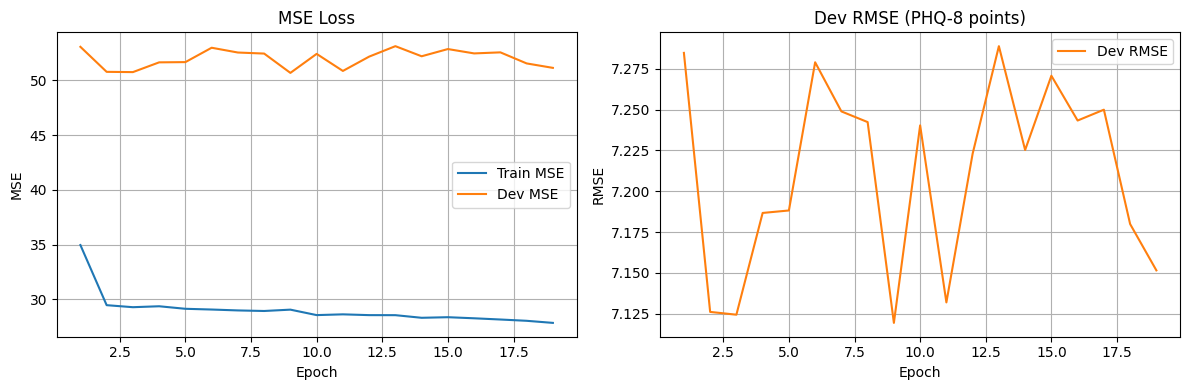

In [6]:
epochs = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, history["train_loss"], label="Train MSE")
axes[0].plot(epochs, history["dev_loss"],   label="Dev MSE")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE")
axes[0].set_title("MSE Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs, history["dev_rmse"], color="tab:orange", label="Dev RMSE")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("RMSE")
axes[1].set_title("Dev RMSE (PHQ-8 points)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 6. Evaluation on Test Set

Loads the best checkpoint and reports participant-level MSE, RMSE, MAE, and Pearson r.
Each participant's segment predictions are averaged into a single score before computing metrics.

In [7]:
# Load best weights
best_ckpt = torch.load(SAVE_DIR / "simple_cnn_best.pth", map_location=DEVICE, weights_only=True)
model.load_state_dict(best_ckpt["model_state_dict"])
print(f"Loaded best model from epoch {best_ckpt['epoch']}  "
      f"(dev MSE {best_ckpt['dev_mse']:.4f})")

# Participant-level predictions on test set
_, _, test_agg = evaluate_participant(test_loader)

all_preds  = test_agg["pred"].values
all_labels = test_agg["label"].values

print(f"  Participants evaluated: {len(test_agg)}")

# Metrics
test_mse  = float(np.mean((all_preds - all_labels) ** 2))
test_rmse = test_mse ** 0.5
test_mae  = float(np.mean(np.abs(all_preds - all_labels)))
test_r, _ = pearsonr(all_preds, all_labels)

print("\n── Test-set results (participant level) ───────────")
print(f"  MSE       : {test_mse:.4f}")
print(f"  RMSE      : {test_rmse:.4f}  PHQ-8 points")
print(f"  MAE       : {test_mae:.4f}  PHQ-8 points")
print(f"  Pearson r : {test_r:.4f}")

Loaded best model from epoch 9  (dev MSE 50.6862)
  Participants evaluated: 47

── Test-set results (participant level) ───────────
  MSE       : 42.8397
  RMSE      : 6.5452  PHQ-8 points
  MAE       : 5.4181  PHQ-8 points
  Pearson r : -0.0780


## 7. Prediction Distribution

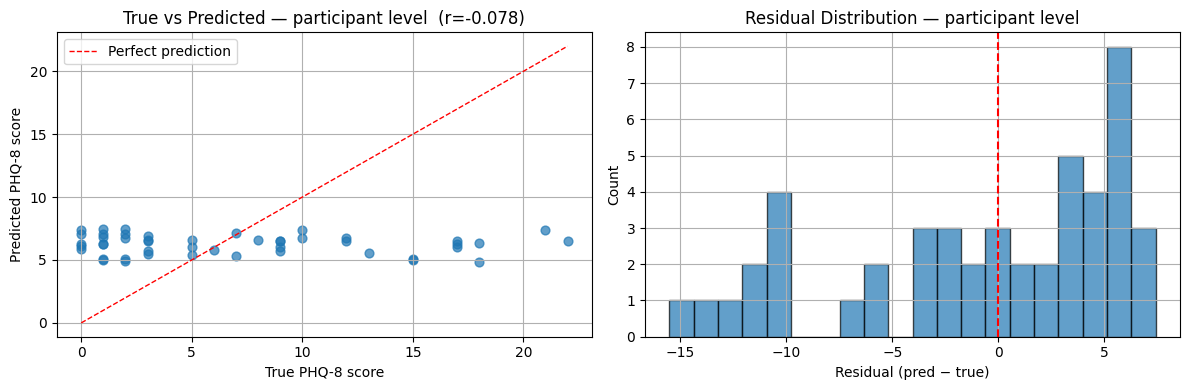

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# One point per participant
axes[0].scatter(all_labels, all_preds, alpha=0.7, s=40)
lo, hi = min(all_labels.min(), all_preds.min()), max(all_labels.max(), all_preds.max())
axes[0].plot([lo, hi], [lo, hi], "r--", linewidth=1, label="Perfect prediction")
axes[0].set_xlabel("True PHQ-8 score")
axes[0].set_ylabel("Predicted PHQ-8 score")
axes[0].set_title(f"True vs Predicted — participant level  (r={test_r:.3f})")
axes[0].legend()
axes[0].grid(True)

residuals = all_preds - all_labels
axes[1].hist(residuals, bins=20, edgecolor="k", alpha=0.7)
axes[1].axvline(0, color="r", linestyle="--")
axes[1].set_xlabel("Residual (pred − true)")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual Distribution — participant level")
axes[1].grid(True)

plt.tight_layout()
plt.show()